# 27.3 - Polynomial Regression

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [9]:
# Building our dataset
X = 6 * np.random.rand(100, 1) - 3
y = 0.5 * X**2 + 1.5*X + 2 + np.random.randn(100, 1) 

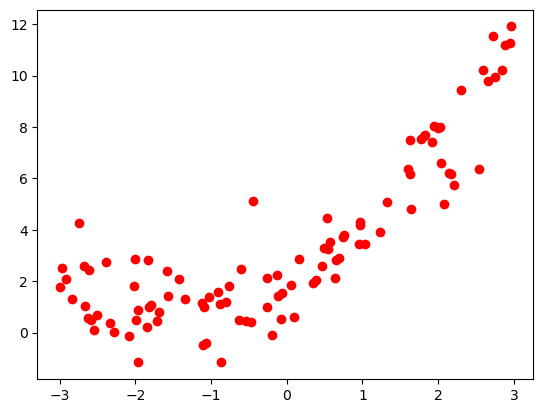

In [10]:
plt.scatter(X, y, color='r')


In [11]:
from sklearn.model_selection import train_test_split


In [12]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [14]:
# lets implement simple linear regression
from sklearn.linear_model import LinearRegression
regression_1 = LinearRegression()

In [15]:
regression_1.fit(X_train, y_train)

LinearRegression()

In [17]:
from sklearn.metrics import r2_score 
score = r2_score(y_test, regression_1.predict(X_test))
print(f"R^2 score for linear regression: {score}")

R^2 score for linear regression: 0.72167718443649


Text(0, 0.5, 'y')

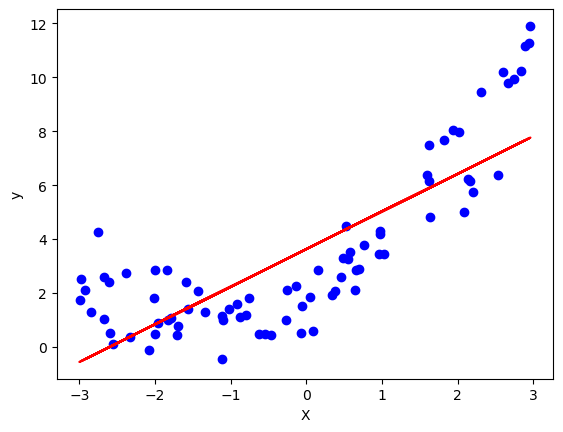

In [18]:
# Visualization
plt.plot(X_train, regression_1.predict(X_train), color='r')
plt.scatter(X_train, y_train, color='b')
plt.xlabel('X')
plt.ylabel('y')

# Now we will solve this using Polynomial Regression.

In [19]:
from sklearn.preprocessing import PolynomialFeatures


## For degree = 2

In [20]:
poly = PolynomialFeatures(degree=2, include_bias=True)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)


In [21]:
regression = LinearRegression()
regression.fit(X_train_poly, y_train)

LinearRegression()

In [22]:
y_pred = regression.predict(X_test_poly)

In [23]:
r2_score_poly = r2_score(y_test, y_pred)
print(f"R^2 score for polynomial regression: {r2_score_poly}")

R^2 score for polynomial regression: 0.8284350696726195


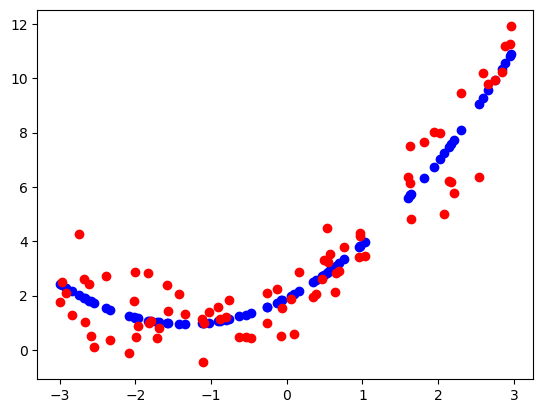

In [25]:
plt.scatter(X_train, regression.predict(X_train_poly), color='b')
plt.scatter(X_train, y_train, color='r')


## For degree = 3

In [ ]:
poly = PolynomialFeatures(degree=3, include_bias=True)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [27]:
regression = LinearRegression()
regression.fit(X_train_poly, y_train)

LinearRegression()

In [28]:
y_pred = regression.predict(X_test_poly)

In [29]:
r2_score_poly = r2_score(y_test, y_pred)
print(f"R^2 score for polynomial regression: {r2_score_poly}")

R^2 score for polynomial regression: 0.8252488079338753


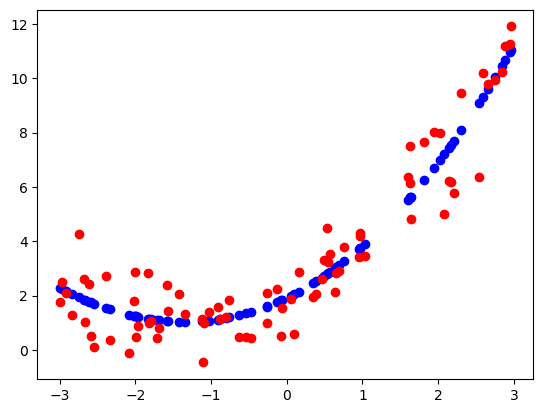

In [30]:
plt.scatter(X_train, regression.predict(X_train_poly), color='b')
plt.scatter(X_train, y_train, color='r')

## Prediction for new data

In [32]:
X_new = np.linspace(-3, 3, 200).reshape(200, 1)
X_new_poly = poly.transform(X_new)

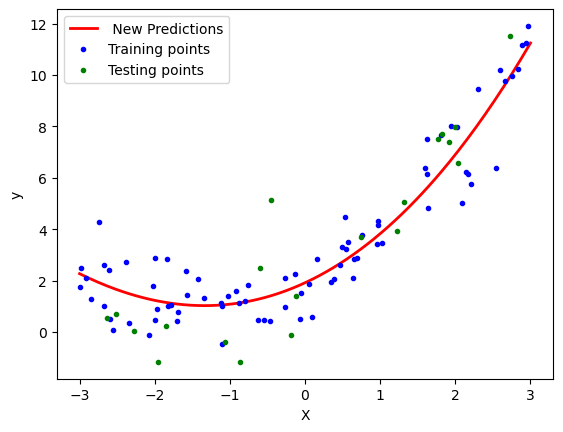

In [33]:
y_new = regression.predict(X_new_poly)
plt.plot(X_new, y_new, "r-", linewidth=2, label=" New Predictions")
plt.plot(X_train, y_train, "b.",label='Training points')
plt.plot(X_test, y_test, "g.",label='Testing points')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

# Pipeline Concept

In [34]:
from sklearn.pipeline import Pipeline

In [35]:
def poly_regression(degree):
  X_new = np.linspace(-3, 3, 200).reshape(200,1)

  poly_features = PolynomialFeatures(degree=degree, include_bias=True)
  lin_reg = LinearRegression()
  poly_regression = Pipeline([
    ('poly_features', poly_features),
    ('lin_reg', lin_reg)
  ])
  poly_regression.fit(X_train, y_train)
  y_pred_new = poly_regression.predict(X_new)

  # ploting the prediction line.
  plt.plot(X_new, y_pred_new, 'r', label='Degree ' + str(degree), linewidth=2)
  plt.plot(X_train, y_train, "b.", linewidth=2)
  plt.plot(X_test, y_test, "g.", linewidth=2)
  plt.xlabel("X")
  plt.ylabel("y")
  plt.axis([-4, 4, 0, 10])
  plt.show()

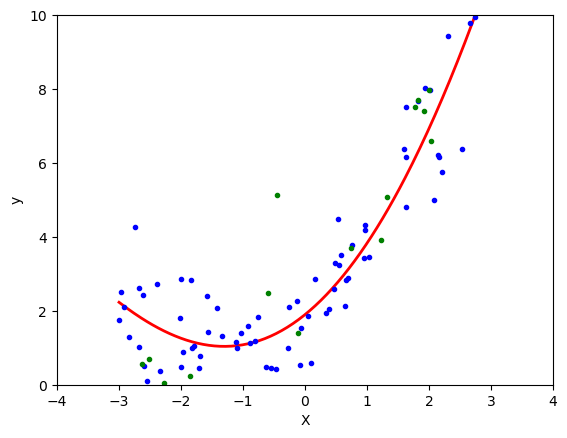

In [47]:
poly_regression(4)